In [28]:
!pip install vaderSentiment


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np

# Load news data
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")

# Load all stock prices
aapl = pd.read_csv("../data/AAPL.csv")
amzn = pd.read_csv("../data/AMZN.csv")
goog = pd.read_csv("../data/GOOG.csv")
meta = pd.read_csv("../data/META.csv")
nvda = pd.read_csv("../data/NVDA.csv")

print("All datasets loaded")

All datasets loaded


In [11]:
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [12]:
news_df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [13]:
aapl["stock"] = "AAPL"
amzn["stock"] = "AMZN"
goog["stock"] = "GOOG"
meta["stock"] = "META"
nvda["stock"] = "NVDA"

In [14]:
stock_df = pd.concat([aapl, amzn, goog, meta, nvda])

print(stock_df.shape)
stock_df.head()

(18019, 7)


,Date,Close,High,Low,Open,Volume,stock
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


In [19]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce').dt.normalize()
stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce').dt.normalize()

In [20]:
news_df['date'] = news_df['date'].dt.date
stock_df['Date'] = stock_df['Date'].dt.date

In [21]:
print(news_df['date'].isna().sum())
print(stock_df['Date'].isna().sum())

1351341
0


In [22]:
news_df['date'].head(20)

0     2020-06-05
1     2020-06-03
2     2020-05-26
3     2020-05-22
4     2020-05-22
5     2020-05-22
6     2020-05-22
7     2020-05-22
8     2020-05-22
9     2020-05-22
10           NaT
11           NaT
12           NaT
13           NaT
14           NaT
15           NaT
16           NaT
17           NaT
18           NaT
19           NaT
Name: date, dtype: object

In [23]:
news_df['date'].dtype

dtype('O')

In [24]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', infer_datetime_format=True)

TypeError: to_datetime() got an unexpected keyword argument 'infer_datetime_format'

In [25]:
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

In [26]:
print(news_df['date'].isna().sum())
print(news_df['date'].head())

1351341
0   2020-06-05
1   2020-06-03
2   2020-05-26
3   2020-05-22
4   2020-05-22
Name: date, dtype: datetime64[s]


In [27]:
news_df = news_df.dropna(subset=['date'])

In [34]:
import json

with open("task3_sentiment_analysis.ipynb", "r", encoding="utf-8") as f:
    json.load(f)

In [33]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'eda_financial_news.ipynb', 'stock_technical_analysis.ipynb', 'task3_sentiment_analysis.ipynb', '__init__.py']


In [35]:
import json

with open("task3_sentiment_analysis.ipynb", "r", encoding="utf-8") as f:
    content = json.load(f)

print("Notebook is valid JSON ✅")

Notebook is valid JSON ✅


In [36]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

news_df.head()

,date,headline,stock,sentiment_score
0,2020-06-05,Stocks That Hit 52-Week Highs On Friday,A,0.000
1,2020-06-03,Stocks That Hit 52-Week Highs On Wednesday,A,0.000
2,2020-05-26,71 Biggest Movers From Friday,A,0.000
3,2020-05-22,46 Stocks Moving In Friday's Mid-Day Session,A,0.000
4,2020-05-22,B of A Securities Maintains Neutral on Agilent...,A,0.296


In [37]:
news_df = news_df[['date', 'headline', 'stock', 'sentiment_score']]
stock_df = stock_df[['Date', 'Close', 'stock']]

In [38]:
daily_sentiment = news_df.groupby(['date', 'stock'])['sentiment_score'].mean().reset_index()
daily_sentiment.head()

,date,stock,sentiment_score
0,2011-04-27,DGP,0.0000
1,2011-04-28,DEJ,0.2500
2,2011-04-28,ESR,0.0000
3,2011-04-29,AIA,0.0000
4,2011-04-29,GDL,0.7351


In [39]:
stock_df['daily_return'] = stock_df.groupby('stock')['Close'].pct_change() * 100
stock_df.head()

,Date,Close,stock,daily_return
0,2009-01-02,2.721686,AAPL,NaN
1,2009-01-05,2.836553,AAPL,4.220416
2,2009-01-06,2.789767,AAPL,-1.649399
3,2009-01-07,2.729484,AAPL,-2.160860
4,2009-01-08,2.780169,AAPL,1.856959


In [40]:
merged = pd.merge(
    stock_df,
    daily_sentiment,
    left_on=['Date', 'stock'],
    right_on=['date', 'stock'],
    how='inner'
)

merged.head()

ValueError: You are trying to merge on object and datetime64[s] columns for key 'Date'. If you wish to proceed you should use pd.concat

In [41]:
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date']).dt.date

In [42]:
merged = pd.merge(
    stock_df,
    daily_sentiment,
    left_on=['Date', 'stock'],
    right_on=['date', 'stock'],
    how='inner'
)

merged.head()

,Date,Close,stock,daily_return,date,sentiment_score
0,2020-06-09,83.419868,AAPL,3.157792,2020-06-09,0.246900
1,2020-06-10,85.566071,AAPL,2.572771,2020-06-10,0.198850
2,2020-06-09,130.042999,AMZN,3.042714,2020-06-09,0.077775
3,2020-06-10,132.372498,AMZN,1.791329,2020-06-10,0.391233
4,2020-06-04,70.129089,GOOG,-1.684800,2020-06-04,0.000000


In [43]:
print(stock_df['Date'].dtype)
print(daily_sentiment['date'].dtype)

object
object


In [46]:
correlations = merged.groupby('stock').apply(
    lambda x: x['sentiment_score'].corr(x['daily_return'])
)

print(correlations)

stock
AAPL    1.000000
AMZN   -1.000000
GOOG   -0.234365
NVDA    0.522731
dtype: float64


In [45]:
print(merged.shape)

(13, 6)


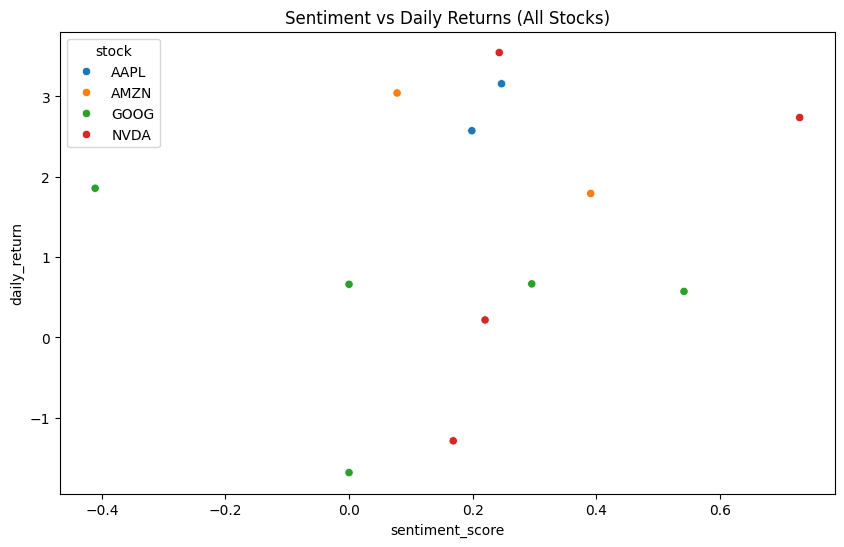

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x='sentiment_score',
    y='daily_return',
    hue='stock'
)

plt.title("Sentiment vs Daily Returns (All Stocks)")
plt.show()

In [48]:
def classify(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    return "Neutral"

merged['sentiment_category'] = merged['sentiment_score'].apply(classify)

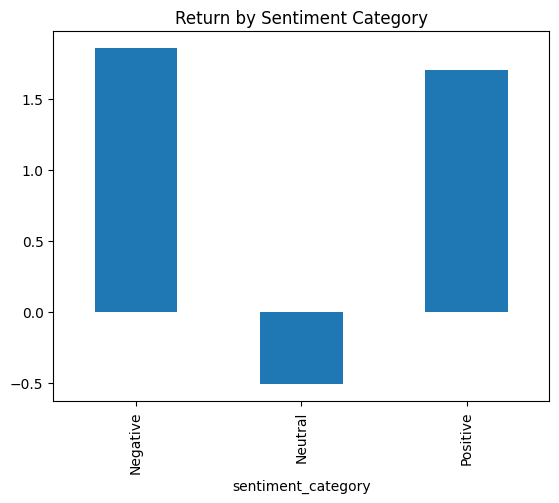

In [49]:
category_returns = merged.groupby('sentiment_category')['daily_return'].mean()

category_returns.plot(kind='bar')
plt.title("Return by Sentiment Category")
plt.show()